In [1]:
!pip install liac-arff
!pip install tldextract
!pip install beautifulsoup4
!pip install whois
!pip install catboost
!pip install ipywidgets
!pip install lightgbm
!pip install xgboost
!pip install tld


[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: C:\Users\zalha\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: C:\Users\zalha\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: C:\Users\zalha\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: C:\Users\zalha\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


   ---------------------------------------- 0.0/102.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/102.5 MB ? eta -:--:--
    --------------------------------------- 1.8/102.5 MB 8.4 MB/s eta 0:00:13
   --- ------------------------------------ 7.9/102.5 MB 18.7 MB/s eta 0:00:06
   ------ --------------------------------- 16.3/102.5 MB 25.6 MB/s eta 0:00:04
   --------- ------------------------------ 24.9/102.5 MB 29.8 MB/s eta 0:00:03
   ------------- -------------------------- 34.3/102.5 MB 32.5 MB/s eta 0:00:03
   ----------------- ---------------------- 44.8/102.5 MB 35.7 MB/s eta 0:00:02
   -------------------- ------------------- 51.9/102.5 MB 34.8 MB/s eta 0:00:02
   ----------------------- ---------------- 60.3/102.5 MB 36.6 MB/s eta 0:00:02
   ---------------------------- ----------- 72.6/102.5 MB 38.0 MB/s eta 0:00:01
   -------------------------------- ------- 82.6/102.5 MB 38.7 MB/s eta 0:00:01
   ----------------------------------- ---- 91.8/102.5 MB 39.

...

   ---------------------------------------- 0.0/914.9 kB ? eta -:--:--
   ---------------------------------------- 0.0/914.9 kB ? eta -:--:--
   ----------- ---------------------------- 262.1/914.9 kB ? eta -:--:--
   --------------------- ---------------- 524.3/914.9 kB 796.8 kB/s eta 0:00:01
   --------------------- ---------------- 524.3/914.9 kB 796.8 kB/s eta 0:00:01
   -------------------------------- ----- 786.4/914.9 kB 699.0 kB/s eta 0:00:01
   -------------------------------- ----- 786.4/914.9 kB 699.0 kB/s eta 0:00:01
   -------------------------------------- 914.9/914.9 kB 623.5 kB/s eta 0:00:00
   ---------------------------------------- 0.0/2.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.2 MB ? eta -:--:--
   ---- ----------------------------------- 0.3/2.2 MB ? eta -:--:--
   ---- --------------------------------


[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: C:\Users\zalha\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: C:\Users\zalha\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: C:\Users\zalha\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: C:\Users\zalha\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [154]:
import arff
import pandas as pd
import numpy as np
import re
import requests
import tldextract
from inspect import Attribute
from urllib.parse import urlparse
from bs4 import BeautifulSoup
import whois
from datetime import datetime
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc,
    roc_auc_score,
    RocCurveDisplay
)
from sklearn.model_selection import learning_curve
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns
from catboost import CatBoostClassifier , Pool
import xgboost as xgb
from tld import get_tld, is_tld
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import string

PREPROCESSING

In [151]:
data = pd.read_csv('phishing+websites/malicious_phish.csv')
# data = data.sample(frac=0.5, random_state=42)
data2 = data

In [152]:
# Clean URL
data['url'] = data['url'].str.replace('www.', '', regex=False)
data['url'] = data['url'].astype(str)

# Labels
label_map = {'benign':0, 'defacement':1, 'phishing':2, 'malware':3}
data['Category'] = data['type'].map(label_map)

# URL length
data['url_len'] = data['url'].str.len()

# Domain extraction
def process_tld(url):
    try:
        res = get_tld(url, as_object=True, fail_silently=True, fix_protocol=True)
        return res.parsed_url.netloc
    except:
        return None
data['domain'] = data['url'].apply(process_tld)

# Symbol counts
syms = ['@','?','-','=','.','#','%','+','$','!','*',',','//']
for s in syms:
    data[s] = data['url'].apply(lambda u: str(u).count(s))

# FIXED abnormal_url
def abnormal_url(url):
    try:
        hostname = urlparse(url).hostname
        return 0 if hostname and url.startswith(('http://' + hostname, 'https://' + hostname)) else 1
    except:
        return 1
data['abnormal_url'] = data['url'].apply(abnormal_url)

# HTTPS
def httpSecure(url):
    htp = urlparse(url).scheme
    match = str(htp)
    if match=='https':
        # print match.group()
        return 1
    else:
        # print 'No matching pattern found'
        return 0
data['https'] = data['url'].apply(lambda i: httpSecure(i))

# Digits & letters
data['digits'] = data['url'].apply(lambda u: sum(c.isdigit() for c in u))
data['letters'] = data['url'].apply(lambda u: sum(c.isalpha() for c in u))

# Shortening service
def Shortining_Service(url):
    return 1 if re.search(
        r'bit\.ly|goo\.gl|tinyurl|t\.co|ow\.ly|adf\.ly|bitly\.com|tinyurl\.com|cutt\.us|j\.mp',
        url, flags=re.I
    ) else 0
data['Shortining_Service'] = data['url'].apply(Shortining_Service)

# IP inside URL
data['having_ip_address'] = data['url'].apply(
    lambda u: 1 if re.search(r'(\d{1,3}\.){3}\d{1,3}', u) else 0
)

# Rename columns
rename_map = {'@':'at', '?':'qmark', '-':'dash', '=':'eq', '.':'dot', '#':'hash',
              '%':'pct', '+':'plus', '$':'dollar', '!':'bang', '*':'star',
              ',':'comma', '//':'double_slash'}
data.rename(columns=rename_map, inplace=True)

# Final dataset
X = data.drop(['url','type','Category','domain'],axis=1)
y = data['Category']

Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, test_size=0.2, random_state=2)


In [ ]:
#URLNet
urls = data['url'].astype(str).tolist()
labels = data['target'].tolist()

char_vocab = {c:i+1 for i,c in enumerate(string.printable)}
max_char_len = 200

def tokenize_words(url):
    return re.split(r'[\/\.\?\=\-&_\:\%]', url)

from collections import Counter
word_counts = Counter()
for u in urls:
    word_counts.update(tokenize_words(u))
word_vocab = {w:i+1 for i,w in enumerate(word_counts)}
max_word_len = 40

def encode_char(url):
    arr = [char_vocab.get(c,0) for c in url[:max_char_len]]
    arr += [0]*(max_char_len-len(arr))
    return torch.tensor(arr)

def encode_word(url):
    tokens = tokenize_words(url)[:max_word_len]
    arr = [word_vocab.get(t,0) for t in tokens]
    arr += [0]*(max_word_len-len(arr))
    return torch.tensor(arr)

class URLDataset(Dataset):
    def __init__(self, urls, labels):
        self.urls = urls
        self.labels = labels
    def __len__(self):
        return len(self.urls)
    def __getitem__(self, idx):
        return encode_char(self.urls[idx]), encode_word(self.urls[idx]), self.labels[idx]

In [ ]:
# with open('phishing+websites\Training Dataset.arff', 'r') as f:
#   arff_data = arff.load(f)
# df = pd.DataFrame(arff_data['data'], columns=[attr[0] for attr in arff_data['attributes']])
# df.head()
# df = pd.DataFrame(arff_data['data'], columns=[attr[0] for attr in arff_data['attributes']])
# df = df.replace('?',np.nan).fillna(0)
# for col in df.columns:
#   if col != 'Result':
#     df[col] = pd.to_numeric(df[col], errors='coerce')
# df['Result'] = pd.to_numeric(df['Result'], errors='coerce').replace(-1,0)
# df = df[df['Result'].isin([0,1])]
# X = df.drop(columns=['Result'])
# y = df['Result']

# # selected_features = [
# #     'having_Sub_Domain',
# #     # 'SSLfinal_State', removed due to making the model overfit
# #     'Domain_registeration_length',
# #     'Request_URL',
# #     'Statistical_report',
# #     'Links_in_tags',
# # ]
# # X = df[selected_features]
# # y = df['Result']
# Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, test_size=0.2, random_state=42)
# load + sample
# data = pd.read_csv('phishing+websites/malicious_phish.csv')
# data = data.sample(frac=0.5, random_state=42)

# # basic cleaning
# data['url'] = data['url'].replace('www.', '', regex=True)
# data['Category'] = data['type'].map({'benign':0, 'defacement':1, 'phishing':2, 'malware':3})
# data['url_len'] = data['url'].astype(str).apply(len)

# # domain extraction
# def process_tld(url):
#     try:
#         res = get_tld(url, as_object=True, fail_silently=False, fix_protocol=True)
#         return res.parsed_url.netloc
#     except:
#         return None
# data['domain'] = data['url'].apply(process_tld)

# # token counts
# feature_symbols = ['@','?','-','=','.','#','%','+','$','!','*',',','//']
# for s in feature_symbols:
#     data[s] = data['url'].astype(str).apply(lambda x: x.count(s))

# # other features
# data['abnormal_url'] = data['url'].apply(lambda u: 1 if re.search(str(urlparse(u).hostname), u or '') else 0)
# data['https'] = data['url'].apply(lambda u: 1 if urlparse(u).scheme == 'https' else 0)
# data['digits'] = data['url'].astype(str).apply(lambda u: sum(ch.isnumeric() for ch in u))
# data['letters'] = data['url'].astype(str).apply(lambda u: sum(ch.isalpha() for ch in u))

# def Shortining_Service(url):
#     return 1 if re.search(r'bit\.ly|goo\.gl|tinyurl|t\.co|ow\.ly|adf\.ly|bitly\.com|tinyurl\.com|cutt\.us|j\.mp', str(url), flags=re.I) else 0
# data['Shortining_Service'] = data['url'].apply(Shortining_Service)

# def having_ip_address(url):
#     return 1 if re.search(r'(\d{1,3}\.){3}\d{1,3}|0x[0-9a-fA-F]+', str(url)) else 0
# data['having_ip_address'] = data['url'].apply(having_ip_address)

# # rename symbol columns to safe names
# rename_map = {'@':'at', '?':'qmark', '-':'dash', '=':'eq', '.':'dot', '#':'hash', '%':'pct',
#               '+':'plus', '$':'dollar', '!':'bang', '*':'star', ',':'comma', '//':'double_slash'}
# data.rename(columns=rename_map, inplace=True)

# # prepare X and y
# X = data.drop(columns=['url', 'type', 'Category', 'domain'])
# y = data['Category'].astype(int)

# # ensure numeric and no NaNs in features
# X = X.fillna(0)
# for c in X.columns:
#     X[c] = pd.to_numeric(X[c], errors='coerce').fillna(0).astype(int)

# # remap labels to contiguous range if needed (0..K-1)
# unique_labels = np.sort(y.unique())
# if not np.array_equal(unique_labels, np.arange(len(unique_labels))):
#     label_map = {lab: i for i, lab in enumerate(unique_labels)}
#     y = y.map(label_map).astype(int)

# Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, test_size=0.2, random_state=2)
# print('Xtrain.shape:', Xtrain.shape, 'Xtest.shape:', Xtest.shape, 'labels:', sorted(ytrain.unique()))


In [156]:
# XGBoost
xgb_model = xgb.XGBClassifier(eval_metric='logloss', random_state=42)
xgb_model.fit(Xtrain, ytrain)
y_pred_xgb = xgb_model.predict(Xtest)
# Evaluate XGBoost
print("XGBoost Model Evaluation Metrics:\n")
print("Accuracy:", accuracy_score(ytest, y_pred_xgb))
print("Confusion Matrix:\n", confusion_matrix(ytest, y_pred_xgb))
print("Classification Report:", classification_report(ytest, y_pred_xgb, target_names=["benign(0)", "defacement(1)", "phishing(2)", "malware(3)"]))


XGBoost Model Evaluation Metrics:

Accuracy: 0.8893188676202981
Confusion Matrix:
 [[84936   240   359    30]
 [  466 18645   168    40]
 [10403  1481  6720   201]
 [  211   511   305  5523]]
Classification Report:                precision    recall  f1-score   support

    benign(0)       0.88      0.99      0.94     85565
defacement(1)       0.89      0.97      0.93     19319
  phishing(2)       0.89      0.36      0.51     18805
   malware(3)       0.95      0.84      0.89      6550

     accuracy                           0.89    130239
    macro avg       0.91      0.79      0.82    130239
 weighted avg       0.89      0.89      0.87    130239



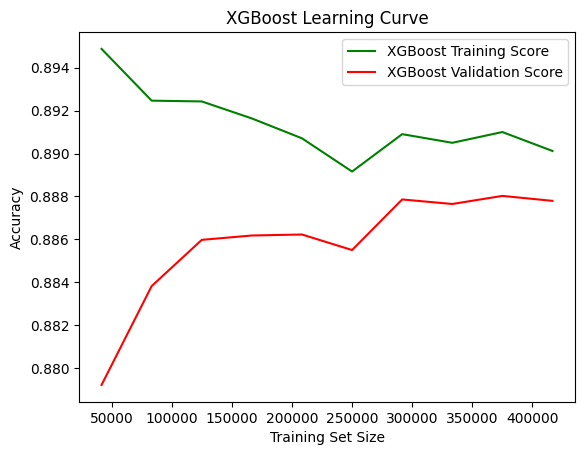

In [157]:
# Learning curve for XGBoost
train_sizes, train_scores, test_scores = learning_curve(
    xgb_model,
    Xtrain, ytrain,
    cv=5,
    scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 10)
)
train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

plt.figure()
plt.plot(train_sizes, train_mean, label="XGBoost Training Score", color="green")
plt.plot(train_sizes, test_mean, label="XGBoost Validation Score", color="red")
plt.title("XGBoost Learning Curve")
plt.xlabel("Training Set Size")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [158]:
#LGBM
lgb_model = lgb.LGBMClassifier(verbose=-1)
lgb_model.fit(Xtrain, ytrain)
y_pred = lgb_model.predict(Xtest)
# Evaluate
print("Model Evaluation Metrics:\n")
print("Accuracy:", accuracy_score(ytest, y_pred))
print("Confusion Matrix:\n", confusion_matrix(ytest, y_pred))
print("Classification Report:\n", classification_report(ytest, y_pred, target_names=["benign(0)", "defacement(1)", "phishing(2)", "malware(3)"]))


Model Evaluation Metrics:

Accuracy: 0.8847733781739725
Confusion Matrix:
 [[85016   248   277    24]
 [  499 18609   156    55]
 [10906  1533  6135   231]
 [  245   538   295  5472]]
Classification Report:
                precision    recall  f1-score   support

    benign(0)       0.88      0.99      0.93     85565
defacement(1)       0.89      0.96      0.92     19319
  phishing(2)       0.89      0.33      0.48     18805
   malware(3)       0.95      0.84      0.89      6550

     accuracy                           0.88    130239
    macro avg       0.90      0.78      0.81    130239
 weighted avg       0.89      0.88      0.86    130239



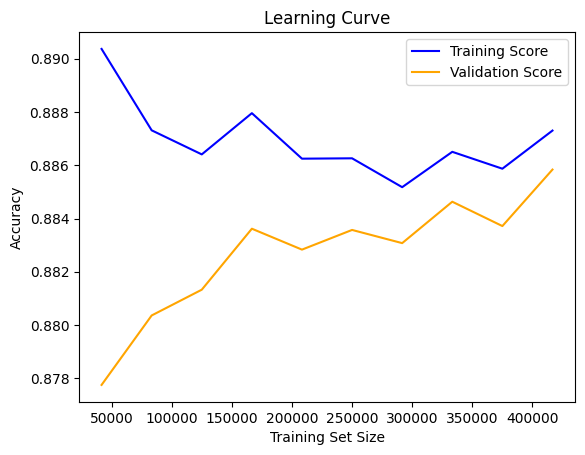

In [159]:
train_sizes, train_scores, test_scores = learning_curve(
        lgb_model,
        Xtrain, ytrain,
        cv=5,
        scoring='accuracy',
        train_sizes=np.linspace(0.1, 1.0, 10)
)
train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

plt.figure()
plt.plot(train_sizes, train_mean, label="Training Score", color="blue")
plt.plot(train_sizes, test_mean, label="Validation Score", color="orange")
plt.title("Learning Curve")
plt.xlabel("Training Set Size")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [160]:
#catboost
catmodel = CatBoostClassifier(
    iterations=100, depth=9,verbose=50,
)
catmodel.fit(Xtrain, ytrain,
          eval_set=(Xtest, ytest))
y_test_pred = catmodel.predict(Xtest)
print("Model Evaluation Metrics:\n")
print("Accuracy:", accuracy_score(ytest, y_test_pred))
print("Confusion Matrix:\n", confusion_matrix(ytest, y_test_pred))
print("Classification Report:\n", classification_report(ytest, y_test_pred, target_names=["benign(0)", "defacement(1)", "phishing(2)", "malware(3)"]))

Learning rate set to 0.294893
0:	learn: 0.8988446	test: 0.8983102	best: 0.8983102 (0)	total: 536ms	remaining: 53.1s
50:	learn: 0.3231705	test: 0.3236540	best: 0.3236540 (50)	total: 22.1s	remaining: 21.2s
99:	learn: 0.2935785	test: 0.2957976	best: 0.2957976 (99)	total: 42.2s	remaining: 0us

bestTest = 0.2957975559
bestIteration = 99

Model Evaluation Metrics:

Accuracy: 0.8900636522086318
Confusion Matrix:
 [[84704   280   545    36]
 [  535 18526   183    75]
 [ 9662  1535  7332   276]
 [  204   624   363  5359]]
Classification Report:
                precision    recall  f1-score   support

    benign(0)       0.89      0.99      0.94     85565
defacement(1)       0.88      0.96      0.92     19319
  phishing(2)       0.87      0.39      0.54     18805
   malware(3)       0.93      0.82      0.87      6550

     accuracy                           0.89    130239
    macro avg       0.89      0.79      0.82    130239
 weighted avg       0.89      0.89      0.87    130239



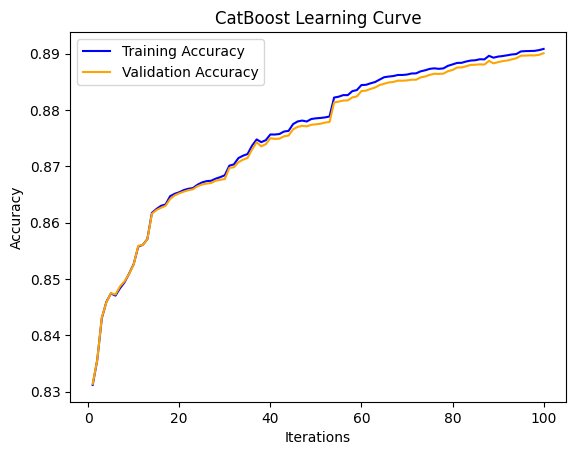

In [161]:
eval_results = catmodel.eval_metrics(Pool(Xtest, ytest), metrics=['MultiClass'])

train_acc = []
val_acc = []

for i in range(catmodel.tree_count_):
    # predict on train and test using first i+1 trees
    ytrain_pred = catmodel.predict(Xtrain, ntree_end=i+1)
    ytest_pred = catmodel.predict(Xtest, ntree_end=i+1)
    
    train_acc.append(accuracy_score(ytrain, ytrain_pred))
    val_acc.append(accuracy_score(ytest, ytest_pred))

# Plot learning curve
plt.figure()
plt.plot(range(1, len(train_acc)+1), train_acc, label="Training Accuracy", color="blue")
plt.plot(range(1, len(val_acc)+1), val_acc, label="Validation Accuracy", color="orange")
plt.xlabel("Iterations")
plt.ylabel("Accuracy")
plt.title("CatBoost Learning Curve")
plt.legend()
plt.show()

In [ ]:
#URLnet
